#MindTrack

##Import Library

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sl
import nltk
import ast


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import Ridge

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
import joblib
import json

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##Gathering Data

In [196]:
stress_df_test = pd.read_csv("https://raw.githubusercontent.com/Infact27/MindTrack/refs/heads/main/Data/dreaddit_test.csv")
stress_df_train = pd.read_csv("https://raw.githubusercontent.com/Infact27/MindTrack/refs/heads/main/Data/dreaddit_train.csv")

emotion_df_test = pd.read_csv("https://raw.githubusercontent.com/Infact27/MindTrack/refs/heads/main/Data/go_emotions_simplified_test.csv")
emotion_df_train = pd.read_csv("https://raw.githubusercontent.com/Infact27/MindTrack/refs/heads/main/Data/go_emotions_simplified_train.csv")
emotion_df_validation = pd.read_csv("https://raw.githubusercontent.com/Infact27/MindTrack/refs/heads/main/Data/go_emotions_simplified_validation.csv")

phq9_df = pd.read_csv("https://raw.githubusercontent.com/Infact27/MindTrack/refs/heads/main/Data/synthetic_phq9_dataset.csv")

##Data Processing

###Preparing Datasets

Merging stress datasets

In [197]:
frames = [stress_df_train, stress_df_test]
stress_df = pd.concat(frames)
stress_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3553 entries, 0 to 714
Columns: 116 entries, subreddit to sentiment
dtypes: float64(106), int64(6), object(4)
memory usage: 3.2+ MB


Merging emotion datasets

In [198]:
frames = [emotion_df_test, emotion_df_train, emotion_df_validation]
emotion_df = pd.concat(frames)
emotion_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54263 entries, 0 to 5425
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    54263 non-null  object
 1   labels  54263 non-null  object
 2   id      54263 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


make a new stress dataframe with necessary columns

In [199]:
print(stress_df.columns.tolist())
print(emotion_df.columns.tolist())
print(phq9_df.columns.tolist())


['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label', 'confidence', 'social_timestamp', 'social_karma', 'syntax_ari', 'lex_liwc_WC', 'lex_liwc_Analytic', 'lex_liwc_Clout', 'lex_liwc_Authentic', 'lex_liwc_Tone', 'lex_liwc_WPS', 'lex_liwc_Sixltr', 'lex_liwc_Dic', 'lex_liwc_function', 'lex_liwc_pronoun', 'lex_liwc_ppron', 'lex_liwc_i', 'lex_liwc_we', 'lex_liwc_you', 'lex_liwc_shehe', 'lex_liwc_they', 'lex_liwc_ipron', 'lex_liwc_article', 'lex_liwc_prep', 'lex_liwc_auxverb', 'lex_liwc_adverb', 'lex_liwc_conj', 'lex_liwc_negate', 'lex_liwc_verb', 'lex_liwc_adj', 'lex_liwc_compare', 'lex_liwc_interrog', 'lex_liwc_number', 'lex_liwc_quant', 'lex_liwc_affect', 'lex_liwc_posemo', 'lex_liwc_negemo', 'lex_liwc_anx', 'lex_liwc_anger', 'lex_liwc_sad', 'lex_liwc_social', 'lex_liwc_family', 'lex_liwc_friend', 'lex_liwc_female', 'lex_liwc_male', 'lex_liwc_cogproc', 'lex_liwc_insight', 'lex_liwc_cause', 'lex_liwc_discrep', 'lex_liwc_tentat', 'lex_liwc_certain', 'lex_liwc_differ', 'lex_liwc_

In [200]:
new_stress_df = stress_df[['text', 'label']]

In [201]:
new_stress_df.head()

,text,label
0,"He said he had not felt that way before, sugge...",1
1,"Hey there r/assistance, Not sure if this is th...",0
2,My mom then hit me with the newspaper and it s...,1
3,"until i met my new boyfriend, he is amazing, h...",1
4,October is Domestic Violence Awareness Month a...,1


In [202]:
emotion_df.head()

,text,labels,id
0,I’m really sorry about your situation :( Altho...,[25],eecwqtt
1,It's wonderful because it's awful. At not with.,[0],ed5f85d
2,"Kings fan here, good luck to you guys! Will be...",[13],een27c3
3,"I didn't know that, thank you for teaching me ...",[15],eelgwd1
4,They got bored from haunting earth for thousan...,[27],eem5uti


In [203]:
phq9_df.head()

,journal_text,phq9_score,severity
0,"I'm generally fine, no major stress lately.",0,minimal
1,"I'm generally fine, no major stress lately.",0,minimal
2,"I feel okay today, just a bit tired but nothin...",2,minimal
3,"I feel okay today, just a bit tired but nothin...",4,minimal
4,"I feel okay today, just a bit tired but nothin...",0,minimal


Checking null value

In [204]:
new_stress_df.isnull().sum()

,0
text,0
label,0


In [205]:
emotion_df.isnull().sum()

,0
text,0
labels,0
id,0


###Text Processing

####Cleaning text

In [206]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    #text cleaning
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"\d+", "", text)                 # remove numbers
    text = re.sub(r"[^\w\s]", "", text)             # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()        # remove extra spaces

    #remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]

    #lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

In [207]:
new_stress_df['clean_text'] = new_stress_df['text'].apply(preprocess_text)
emotion_df['clean_text'] = emotion_df['text'].apply(preprocess_text)
phq9_df['clean_text'] = phq9_df['journal_text'].apply(preprocess_text)

/tmp/ipython-input-1786566976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_stress_df['clean_text'] = new_stress_df['text'].apply(preprocess_text)


In [208]:
new_stress_df.head(2)

,text,label,clean_text
0,"He said he had not felt that way before, sugge...",1,said felt way suggeted go rest trigger ahead y...
1,"Hey there r/assistance, Not sure if this is th...",0,hey rassistance sure right place post go im cu...


In [209]:
emotion_df.head(2)

,text,labels,id,clean_text
0,I’m really sorry about your situation :( Altho...,[25],eecwqtt,im really sorry situation although love name s...
1,It's wonderful because it's awful. At not with.,[0],ed5f85d,wonderful awful


In [210]:
phq9_df.head(2)

,journal_text,phq9_score,severity,clean_text
0,"I'm generally fine, no major stress lately.",0,minimal,im generally fine major stress lately
1,"I'm generally fine, no major stress lately.",0,minimal,im generally fine major stress lately


###EDA

In [211]:
emotion_df['labels'].value_counts(normalize=True)

,proportion
labels,
[27],0.295247
[0],0.062363
[15],0.043824
[4],0.043621
[1],0.037705
...,...
"[1, 3, 17]",0.000018
"[7, 14, 22]",0.000018
"[0, 1, 13]",0.000018


Ada beberapa data pada emotion_df yang memiliki lebih dari 1 label (gunakan multi label classification)

In [212]:
new_stress_df['label'].value_counts(normalize=True) * 100

,proportion
label,
1,52.265691
0,47.734309


proporsi label pada stress_df condong pada 1 (stress)

In [213]:
phq9_df['phq9_score'].describe()

,phq9_score
count,1500.000000
mean,12.334000
std,7.671354
min,0.000000
25%,6.000000
50%,12.000000
75%,18.000000
max,27.000000


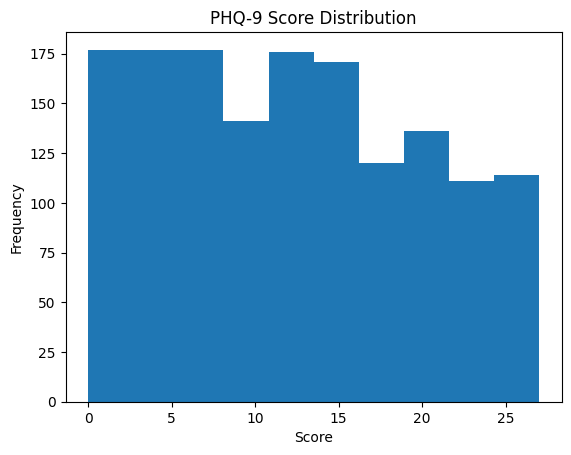

In [214]:
plt.hist(phq9_df['phq9_score'], bins=10)
plt.title("PHQ-9 Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [215]:
phq9_df['severity'].value_counts(normalize=True) * 100

,proportion
severity,
minimal,20.0
mild,20.0
moderate,20.0
moderately_severe,20.0
severe,20.0


data pada phq9_df seimbang

In [216]:
emotion_df['text_len'] = emotion_df['clean_text'].str.split().str.len()
emotion_df['text_len'].describe()

,text_len
count,54263.000000
mean,6.783333
std,3.553639
min,0.000000
25%,4.000000
50%,6.000000
75%,9.000000
max,28.000000


In [217]:
new_stress_df['text_len'] = new_stress_df['clean_text'].str.split().str.len()
new_stress_df['text_len'].describe()

/tmp/ipython-input-157057332.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_stress_df['text_len'] = new_stress_df['clean_text'].str.split().str.len()


,text_len
count,3553.000000
mean,40.133690
std,15.011234
min,1.000000
25%,30.000000
50%,38.000000
75%,47.000000
max,149.000000


In [218]:
phq9_df['text_len'] = phq9_df['clean_text'].str.split().str.len()
phq9_df['text_len'].describe()

,text_len
count,1500.000000
mean,5.856667
std,1.101331
min,3.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,7.000000


Sebagian besar teks bersifat pendek hingga menengah, menunjukkan bahwa pendekatan berbasis kata (TF-IDF) sudah memadai tanpa memerlukan model NLP kompleks.

In [219]:
tfidf_probe = TfidfVectorizer(max_features=20)
tfidf_probe.fit_transform(emotion_df['clean_text'])

tfidf_probe.get_feature_names_out()

array(['dont', 'get', 'good', 'im', 'know', 'like', 'lol', 'love', 'make',
       'name', 'one', 'people', 'really', 'thanks', 'thats', 'thing',
       'think', 'time', 'would', 'youre'], dtype=object)

Masih banyak kata yang umum seperti (get, make, think) dan kata untuk percakapan seperti  (im, youre, lol)

kata - kata yang mengekspresikan emosi belum cukup kuat, mungkin emosi diekspresikan menggunakan frasa.

In [220]:
tfidf_probe.fit_transform(new_stress_df['clean_text'])
tfidf_probe.get_feature_names_out()

array(['day', 'dont', 'even', 'feel', 'friend', 'get', 'go', 'help', 'im',
       'ive', 'know', 'like', 'one', 'people', 'really', 'thing', 'time',
       'want', 'would', 'year'], dtype=object)

stress_df lebih baik dari emotion_df, tapi masih cukup umum

In [221]:
tfidf_probe.fit_transform(phq9_df['clean_text'])
tfidf_probe.get_feature_names_out()

array(['bed', 'bit', 'energy', 'extremely', 'feel', 'find', 'forward',
       'get', 'hard', 'im', 'keep', 'lately', 'lower', 'mood',
       'overwhelmed', 'responsibility', 'sometimes', 'stress', 'task',
       'usual'], dtype=object)

phq9 sudah baik

menghilangkan kata - kata umum dari emotion_df

In [222]:
def remove_custom_stopword(text):

    custom_stopwords = stop_words.union({
    'lol', 'thanks', 'youre', 'im', 'dont', 'get', 'name'
    })
    #remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in custom_stopwords]

    return " ".join(tokens)

emotion_df['clean_text'] = emotion_df['clean_text'].apply(remove_custom_stopword)

In [223]:
tfidf_probe = TfidfVectorizer(
    max_features=20,
    ngram_range=(3,3), #allowing only trigram
)

tfidf_probe.fit_transform(emotion_df['clean_text'])
tfidf_probe.get_feature_names_out()

array(['cant wait see', 'didnt even know', 'doesnt seem like',
       'every single time', 'every time see', 'happy cake day',
       'happy new year', 'hope feel better', 'id love see',
       'ive ever seen', 'ive never heard', 'ive never seen',
       'long time ago', 'make feel better', 'make look like',
       'make lot sense', 'thank kind word', 'thing ive ever',
       'thing ive seen', 'would love see'], dtype=object)

hal ini memastikan bahwa emosi diekspresikan melalui frasa, bukan 1 kata saja.

sehingga waktu modelling akan menggunakan ngram_range=(1,3)

##Modelling

Note :

emotion_df menggunakan Multi-Label Classification (multiple emotion)

new_stress_df menggunakan Binary Classification (1/0)

phq9_df menggunakan Regression (0-27)

###Emotion Model

In [224]:
emotion_df['labels'].apply(type).value_counts()

,count
labels,
<class 'str'>,54263


In [225]:
emotion_df['labels'] = emotion_df['labels'].apply(ast.literal_eval)

In [226]:
emotion_df['labels'].apply(type).value_counts()

,count
labels,
<class 'list'>,54263


In [227]:
# Convert labels to multi-hot vectors
X = emotion_df['clean_text']
y = emotion_df['labels']

mlb = MultiLabelBinarizer()
y_bin = mlb.fit_transform(y)

print(mlb.classes_)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27]


In [228]:
y_bin = mlb.fit_transform(y)

# Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_bin,
    test_size=0.15,
    random_state=42
)

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # 0.1765 × 0.85 ≈ 0.15
    random_state=42
)

# 70% train
# 15% validation
# 15% test

In [229]:
# Build pipeline :
      # Prevents data leakage
      # Guarantees same preprocessing at train & test
      # Cleaner, reproducible experiments

emotion_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        # parameter dihilangkan untuk melakukan gridsearch
        # max_features=15000,
        # ngram_range=(1,3),

        # masukkan parameter berdasarkan hasil gridsearch
        max_features = 20000,
        ngram_range = (1,3),
        min_df = 2
    )),
    ('clf', OneVsRestClassifier(
        LogisticRegression(
            C = 3.0,
            max_iter=1000,
            # menambahkan class weight
            class_weight='balanced',
        )
    ))
])

# train model
emotion_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 3))),
                ('clf',
                 OneVsRestClassifier(estimator=LogisticRegression(C=3.0,
                                                                  class_weight='balanced',
                                                                  max_iter=1000)))])

In [230]:
# # Parameter Grid
# param_grid = {
#     'tfidf__max_features': [10000, 15000, 20000],
#     'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
#     'tfidf__min_df': [2, 5],
#     'clf__estimator__C': [0.3, 1.0, 3.0]
# }

# # membuat gridsearch
# grid = GridSearchCV(
#     estimator=emotion_model,
#     param_grid=param_grid,
#     scoring='f1_micro',   # aligns with your primary metric
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train, y_train)

# best_model = grid.best_estimator_

# print("Best parameters:")
# print(grid.best_params_)

'''
output :
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters:
{'clf__estimator__C': 3.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3)}
'''

"\noutput :\nFitting 3 folds for each of 54 candidates, totalling 162 fits\nBest parameters:\n{'clf__estimator__C': 3.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3)}\n"

In [231]:
# Get probabilities on VALIDATION data

# y_val_prob = emotion_model.predict_proba(X_val)

# # Try different thresholds on VALIDATION data

# def apply_threshold(y_prob, threshold):
#     return (y_prob >= threshold).astype(int)

# for t in [0.5, 0.6, 0.65, 0.7, 0.8]:
#     y_val_pred = apply_threshold(y_val_prob, t)
#     print(f"\nValidation results — Threshold = {t}")
#     print(classification_report(
#         y_val,
#         y_val_pred,
#         target_names=[str(i) for i in mlb.classes_],
#         zero_division=0
#     ))

    # best global threshold output = 0.7

In [232]:
# mencari threshold per-label
y_val_prob = emotion_model.predict_proba(X_val)

threshold_grid = np.arange(0.1, 0.91, 0.05)
n_labels = y_val.shape[1]

best_thresholds = np.zeros(n_labels)
best_f1_scores = np.zeros(n_labels)

for label_idx in range(n_labels):
    y_true_label = y_val[:, label_idx]
    y_prob_label = y_val_prob[:, label_idx]

    best_f1 = 0
    best_t = 0.5  # safe default

    for t in threshold_grid:
        y_pred_label = (y_prob_label >= t).astype(int)

        # skip invalid cases
        if y_pred_label.sum() == 0 and y_true_label.sum() == 0:
            continue

        f1 = f1_score(
            y_true_label,
            y_pred_label,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label_idx] = best_t
    best_f1_scores[label_idx] = best_f1

# menunjukkan threshold yang di dapat
    # for i, t in enumerate(best_thresholds):
    #   print(f"Label {mlb.classes_[i]} → threshold={t:.2f}, F1={best_f1_scores[i]:.3f}")

'''
hasil :
Label 0 → threshold=0.65, F1=0.830
Label 1 → threshold=0.75, F1=0.786
Label 2 → threshold=0.80, F1=0.807
Label 3 → threshold=0.70, F1=0.728
Label 4 → threshold=0.70, F1=0.740
Label 5 → threshold=0.85, F1=0.803
Label 6 → threshold=0.80, F1=0.785
Label 7 → threshold=0.75, F1=0.714
Label 8 → threshold=0.90, F1=0.828
Label 9 → threshold=0.80, F1=0.782
Label 10 → threshold=0.75, F1=0.759
Label 11 → threshold=0.85, F1=0.872
Label 12 → threshold=0.90, F1=0.924
Label 13 → threshold=0.85, F1=0.789
Label 14 → threshold=0.90, F1=0.904
Label 15 → threshold=0.70, F1=0.831
Label 16 → threshold=0.90, F1=0.773
Label 17 → threshold=0.75, F1=0.836
Label 18 → threshold=0.85, F1=0.879
Label 19 → threshold=0.90, F1=0.857
Label 20 → threshold=0.80, F1=0.837
Label 21 → threshold=0.90, F1=0.738
Label 22 → threshold=0.80, F1=0.852
Label 23 → threshold=0.90, F1=0.807
Label 24 → threshold=0.90, F1=0.865
Label 25 → threshold=0.80, F1=0.827
Label 26 → threshold=0.85, F1=0.828
Label 27 → threshold=0.55, F1=0.750
'''

'\nhasil :\nLabel 0 → threshold=0.65, F1=0.830\nLabel 1 → threshold=0.75, F1=0.786\nLabel 2 → threshold=0.80, F1=0.807\nLabel 3 → threshold=0.70, F1=0.728\nLabel 4 → threshold=0.70, F1=0.740\nLabel 5 → threshold=0.85, F1=0.803\nLabel 6 → threshold=0.80, F1=0.785\nLabel 7 → threshold=0.75, F1=0.714\nLabel 8 → threshold=0.90, F1=0.828\nLabel 9 → threshold=0.80, F1=0.782\nLabel 10 → threshold=0.75, F1=0.759\nLabel 11 → threshold=0.85, F1=0.872\nLabel 12 → threshold=0.90, F1=0.924\nLabel 13 → threshold=0.85, F1=0.789\nLabel 14 → threshold=0.90, F1=0.904\nLabel 15 → threshold=0.70, F1=0.831\nLabel 16 → threshold=0.90, F1=0.773\nLabel 17 → threshold=0.75, F1=0.836\nLabel 18 → threshold=0.85, F1=0.879\nLabel 19 → threshold=0.90, F1=0.857\nLabel 20 → threshold=0.80, F1=0.837\nLabel 21 → threshold=0.90, F1=0.738\nLabel 22 → threshold=0.80, F1=0.852\nLabel 23 → threshold=0.90, F1=0.807\nLabel 24 → threshold=0.90, F1=0.865\nLabel 25 → threshold=0.80, F1=0.827\nLabel 26 → threshold=0.85, F1=0.828\

In [233]:
# mengambil threshold 0.2 karena memiliki micro F1 paling tinggi (primary metric)
# FINAL_THRESHOLD = 0.2

"""
mengubah threshold menjadi 0.65 setelah class weighting karena
  - micro F1 tertinggi
  - Strong samples F1
  - Recall masih cukup tinggi untuk label dengan sedikit support
  - Precision cukup tinggi
"""
# FINAL_THRESHOLD = 0.65

# menggabungkan train dan validation data
X_train_final = pd.concat([X_train, X_val])
y_train_final = np.vstack([y_train, y_val])

# melatih ulang model menggunakan data train dan validation
emotion_model.fit(X_train_final, y_train_final)

# mengambil probability
y_test_prob = emotion_model.predict_proba(X_test)

# menggunakan global threshold yang sudah ditentukan
# y_test_pred = apply_threshold(y_test_prob, FINAL_THRESHOLD)


# menggunakan threshold per-label
y_test_pred = np.zeros_like(y_test_prob, dtype=int)

for label_idx in range(n_labels):
    y_test_pred[:, label_idx] = (
        y_test_prob[:, label_idx] >= best_thresholds[label_idx]
    ).astype(int)

In [234]:
# evaluation
print(classification_report(
    y_test,
    y_test_pred,
    target_names=[str(i) for i in mlb.classes_],
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.59      0.65      0.62       789
           1       0.49      0.44      0.46       438
           2       0.53      0.51      0.52       285
           3       0.18      0.45      0.26       444
           4       0.23      0.27      0.25       515
           5       0.24      0.39      0.30       214
           6       0.18      0.26      0.21       243
           7       0.18      0.22      0.20       403
           8       0.31      0.47      0.37       120
           9       0.14      0.20      0.17       229
          10       0.11      0.42      0.18       387
          11       0.47      0.36      0.41       162
          12       0.60      0.47      0.53        51
          13       0.25      0.48      0.33       161
          14       0.54      0.48      0.50       141
          15       0.79      0.52      0.63       504
          16       0.22      0.33      0.27        12
          17       0.48    

Note :

Default model :

```
emotion_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1,3),
    )),
    ('clf', OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    ))
])
```
* Precision tinggi
* ada 3 label dengan recall 0, dan beberapa mendekati 0 (recall rendah)
* Model hanya melakukan prediksi saat sangat *confident*
* kesimpulan : model membutuhkan tuning
* langkah selanjutnya :
  * menambahkan validation data pada split
  * melakukan Threshold tuning

model dengan threshold 0.2 :
* rata - rata macro-f1, micro-f1, dan recall meningkat
* masih banyak label yang memiliki recall sangat rendah, label ini memiliki kesamaan yaitu support yang rendah
* kesimpulan : terjadi learning imbalance, banyak label yang dihiraukan
* lengkah selanjutnya :
  * melakukan class weighting


model dengan threshold 0.2 dan class weighting:
* precision menurun dengan drastis
* recall naik dengarn drastis
* label dengan recall rendah membaik
* kesimpulan :
  * class weighting bekerja
  * model menjadi sangat agresif
* langkah selanjutnya :
  * menentukan threshold lagi

model dengan threshold 0.65 dan class weighting:
* tidak ada label yang dihiraukan
* avg f1 score sudah cukup baik
* recall dan precision cukup seimbang
* recall dan precision masih dibawah 0.5
* kesimpulan:
  * model sudah jauh lebih baik dari default model
  * masih membutuhkan tuning untuk meningkatkan precision dan recall
* langkah selanjutnya:
  * menentukan hyperparameter tuning menggunakan GridSearch
  * menggunakan tuning terbaik


model setelah gridsearch:
* average dari precision, recall, dan f1 menjadi lebih balanced tapi masih rendah
* precision dan recall dari setiap label sangat tidak balanced
* kesimpulan:
  * setiap label memiliki threshold yang berbeda
* Langkah selanjutnya:
  * menambahkan per-label threshold


### Stress Model

In [235]:
# Train / test split

X = new_stress_df['clean_text']
y = new_stress_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [236]:
# Build Pipeline
stress_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

# Train Model
stress_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=15000, min_df=5,
                                 ngram_range=(1, 3))),
                ('clf', LogisticRegression(max_iter=1000))])

In [237]:
# Evaluation

y_pred = stress_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.73      0.74       339
           1       0.76      0.77      0.76       372

    accuracy                           0.75       711
   macro avg       0.75      0.75      0.75       711
weighted avg       0.75      0.75      0.75       711

[[249  90]
 [ 87 285]]


Note :

Default Model :


```
stress_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(max_iter=1000))
])
```
* Precision dan recall cukup tinggi
* confusion matrix seimbang
* model sudah cukup baik


###PHQ-9 Model

In [238]:
# Train / Test Split

X = phq9_df['clean_text']
y = phq9_df['phq9_score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [239]:
# Build Pipeline
phq9_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9
    )),
    ('reg', Ridge(alpha=1.0))
])

# Train model
phq9_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=20000, min_df=5,
                                 ngram_range=(1, 2))),
                ('reg', Ridge())])

In [240]:
# Evaluation
y_pred = phq9_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 1.4170730778426495
RMSE: 1.685168267728352


Note :

Default Model :


```
phq9_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9
    )),
    ('reg', Ridge(alpha=1.0))
])
```
* MAE dan RMSE rendah
* model sudah cukup baik



## Save model

In [241]:
joblib.dump(emotion_model, 'emotion_model.joblib')
joblib.dump(mlb, "emotion_mlb.joblib")
joblib.dump(stress_model, 'stress_model.joblib')
joblib.dump(phq9_model, 'phq9_model.joblib')


best_thresholds_json = best_thresholds.tolist()
with open("emotion_thresholds.json", "w") as f:
    json.dump(best_thresholds_json, f)
